In [ ]:
import pandas as pd
from itertools import combinations
import matplotlib.pyplot as plt

In [ ]:
# data transaksi POS
transactions = [
    ['pen', 'bread', 'butter'],
    ['bread', 'butter', 'egg', 'milk'],
    ['vegetables', 'egg', 'milk'],
    ['bread', 'butter'],
    ['bread', 'butter', 'soy sauce', 'egg', 'milk']
]

df = pd.DataFrame({'Products purchased': transactions})

total_transactions = len(df)
print(f'Total Transaksi: {total_transactions}')

df.head()

Total Transaksi: 5


,Products purchased
0,"[pen, bread, butter]"
1,"[bread, butter, egg, milk]"
2,"[vegetables, egg, milk]"
3,"[bread, butter]"
4,"[bread, butter, soy sauce, egg, milk]"


In [ ]:
# Membuat function support, confidence, & lift

def support(products):
    count = 0

    for transaction in transactions:
        # ubah ke set
        product_set = set(products)
        transaction_set = set(transaction)

        # cek apakah semua produk ada di transaksi
        if product_set.issubset(transaction_set):
            count += 1

    return count / total_transactions

def confidence(A, B):
    return support(A + B) / support(A)

def lift(A, B):
    return confidence(A, B) / support(B)

In [ ]:
#List produk questin
list_products = [
    (['bread'], ['butter']),
    (['bread'], ['egg']),
    (['egg'], ['milk']),
    (['bread', 'butter'], ['milk'])
]

In [ ]:
# Menghitung matrik
results = []

for A, B in list_products:
    sup = support(A + B)
    conf = confidence(A, B)
    lf = lift(A, B)

    results.append({
        'list_products': f"{A} => {B}",
        'Support': sup,
        'Confidence': conf,
        'Lift': lf
    })

# Menampilkan hasil dalam DataFrame agar rapi
df_results = pd.DataFrame(results)
print(df_results)

                     list_products  Support  Confidence      Lift
0          ['bread'] => ['butter']      0.8         1.0  1.250000
1             ['bread'] => ['egg']      0.4         0.5  0.833333
2              ['egg'] => ['milk']      0.6         1.0  1.666667
3  ['bread', 'butter'] => ['milk']      0.4         0.5  0.833333


**Analogi Sederhana**

"Beli mie instan $\rightarrow$ beli telur"

Support $\rightarrow$ berapa banyak transaksi ada mie + telur

Confidence $\rightarrow$ dari yang beli mie, berapa yang beli telur

Lift $\rightarrow$ apakah mie benar-benar bikin orang beli telur, atau memang telur sudah sering dibeli semua orang

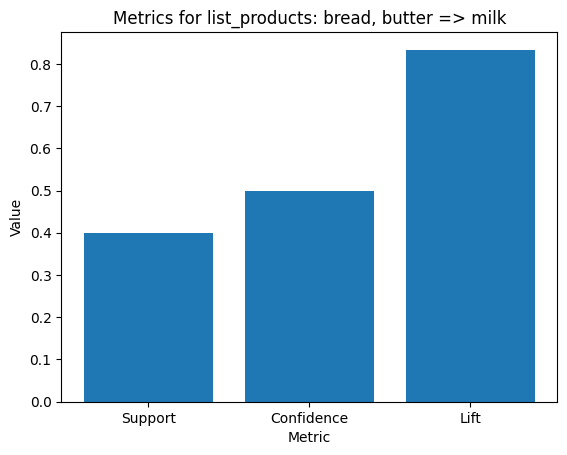

In [ ]:
target_list_products = next(r for r in results if r['list_products'] == "['bread', 'butter'] => ['milk']")

metrics = ['Support', 'Confidence', 'Lift']
values = [target_list_products[m] for m in metrics]

plt.figure()
plt.bar(metrics, values)
plt.title("Metrics for list_products: bread, butter => milk")
plt.xlabel("Metric")
plt.ylabel("Value")
plt.show()

## **Praktikum Mandiri 1**

In [ ]:
import pandas as pd

data = {
    'ID Transaksi': ['T001','T002','T003','T004','T005','T006','T007','T008','T009','T010'],
    'Item': [
        ['Laptop','Mouse','Keyboard','Headset'],
        ['Handphone','Charger','Casing HP'],
        ['Laptop','Mouse','Flashdisk'],
        ['Handphone','Headset','Power Bank','Charger'],
        ['Tablet','Keyboard','Mouse'],
        ['Laptop','Keyboard','Mouse','Headset'],
        ['Handphone','Casing HP','Flashdisk','Charger'],
        ['Laptop','Mouse','Headset','Power Bank'],
        ['Handphone','Charger','Power Bank'],
        ['Tablet','Mouse','Headset','Flashdisk']
    ]
}

df = pd.DataFrame(data)
print(df)

  ID Transaksi                                        Item
0         T001          [Laptop, Mouse, Keyboard, Headset]
1         T002             [Handphone, Charger, Casing HP]
2         T003                  [Laptop, Mouse, Flashdisk]
3         T004   [Handphone, Headset, Power Bank, Charger]
4         T005                   [Tablet, Keyboard, Mouse]
5         T006          [Laptop, Keyboard, Mouse, Headset]
6         T007  [Handphone, Casing HP, Flashdisk, Charger]
7         T008        [Laptop, Mouse, Headset, Power Bank]
8         T009            [Handphone, Charger, Power Bank]
9         T010         [Tablet, Mouse, Headset, Flashdisk]


## **Praktikum Mandiri 2**

In [ ]:
from collections import Counter

all_items = [item for transaksi in df['Item'] for item in transaksi]
freq = Counter(all_items)

total = len(df)

result = []
for item, count in freq.items():
    support = count / total
    transaksi = [df['ID Transaksi'][i] for i in range(len(df)) if item in df['Item'][i]]

    result.append([item, ', '.join(transaksi), count, support])

df_freq = pd.DataFrame(result, columns=['Item','Transaksi','Frekuensi','Support'])
print(df_freq)

         Item                           Transaksi  Frekuensi  Support
0      Laptop              T001, T003, T006, T008          4      0.4
1       Mouse  T001, T003, T005, T006, T008, T010          6      0.6
2    Keyboard                    T001, T005, T006          3      0.3
3     Headset        T001, T004, T006, T008, T010          5      0.5
4   Handphone              T002, T004, T007, T009          4      0.4
5     Charger              T002, T004, T007, T009          4      0.4
6   Casing HP                          T002, T007          2      0.2
7   Flashdisk                    T003, T007, T010          3      0.3
8  Power Bank                    T004, T008, T009          3      0.3
9      Tablet                          T005, T010          2      0.2


## **Praktikum Mandiri 3**

In [ ]:
import pandas as pd

data_pair = [
    ['{Mouse, Headset}', 'T001, T006, T008, T010', 4, 0.4],
    ['{Mouse, Laptop}', 'T001, T003, T006, T008', 4, 0.4],
    ['{Handphone, Charger}', 'T002, T004, T007, T009', 4, 0.4],
    ['{Laptop, Headset}', 'T001, T006, T008', 3, 0.3],
    ['{Mouse, Keyboard}', 'T001, T005, T006', 3, 0.3]
]

df_pair = pd.DataFrame(data_pair, columns=['2-Itemset', 'Transaksi', 'Frekuensi', 'Support'])

print(df_pair)

              2-Itemset               Transaksi  Frekuensi  Support
0      {Mouse, Headset}  T001, T006, T008, T010          4      0.4
1       {Mouse, Laptop}  T001, T003, T006, T008          4      0.4
2  {Handphone, Charger}  T002, T004, T007, T009          4      0.4
3     {Laptop, Headset}        T001, T006, T008          3      0.3
4     {Mouse, Keyboard}        T001, T005, T006          3      0.3


## **Praktikum Mandiri 4**

In [ ]:
import pandas as pd

# Pengaturan agar tampilan tabel di terminal rapi dan tidak terpotong
pd.set_option('display.max_colwidth', None)
pd.set_option('display.width', 1000)

# 1. Data dari praktikum sebelumnya
support_single = {'Mouse': 0.6, 'Headset': 0.5, 'Handphone': 0.4, 'Charger': 0.4}
support_double = {('Handphone', 'Charger'): 0.4, ('Mouse', 'Headset'): 0.4}

# 2. Threshold sesuai instruksi gambar
min_supp = 0.3
min_conf = 0.5

# 3. Fungsi hitung metrik (Logika kamu yang sudah benar)
def get_metrics(item_a, item_b, supp_ab):
    supp_a = support_single[item_a]
    supp_b = support_single[item_b]
    conf = supp_ab / supp_a
    lift = supp_ab / (supp_a * supp_b)
    is_valid = "VALID" if (supp_ab >= min_supp and conf >= min_conf) else "TIDAK VALID"
    return conf, lift, is_valid

# 4. Melakukan perhitungan untuk setiap poin
conf_hp_ch, lift_hp_ch, valid_hp_ch = get_metrics('Handphone', 'Charger', 0.4)
conf_ch_hp, _, _ = get_metrics('Charger', 'Handphone', 0.4)
conf_m_hs, lift_m_hs, valid_m_hs = get_metrics('Mouse', 'Headset', 0.4)
conf_hs_m, _, _ = get_metrics('Headset', 'Mouse', 0.4)

# 5. Menyusun hasil ke dalam List untuk dijadikan DataFrame[cite: 5]
# Format ini mengikuti urutan nomor 1-10 pada image_9fbc17.png
hasil_final = [
    ["1", "Support {Mouse} dan {Headset} secara terpisah", f"Mouse: {support_single['Mouse']}, Headset: {support_single['Headset']}"],
    ["2", "Support 2-itemset {Handphone, Charger}", support_double[('Handphone', 'Charger')]],
    ["3", "Confidence aturan: Handphone => Charger", conf_hp_ch],
    ["4", "Confidence aturan: Charger => Handphone", conf_ch_hp],
    ["5", "Lift untuk aturan: Handphone => Charger", lift_hp_ch],
    ["6", "Support 2-itemset {Mouse, Headset}", support_double[('Mouse', 'Headset')]],
    ["7", "Confidence aturan: Mouse => Headset", round(conf_m_hs, 3)],
    ["8", "Confidence aturan: Headset => Mouse", conf_hs_m],
    ["9", "Lift untuk aturan: Mouse => Headset", round(lift_m_hs, 3)],
    ["10", "Kesimpulan (VALID jika Sup >= 0.3 & Conf >= 0.5)", f"HP=>Charger ({valid_hp_ch}) & Mouse=>Headset ({valid_m_hs})"]
]

# 6. Membuat DataFrame[cite: 5]
df_praktikum_4 = pd.DataFrame(hasil_final, columns=['No', 'Pertanyaan', 'Hasil Perhitungan'])

# 7. Menampilkan hasil akhir
print("--- HASIL PRAKTIKUM MANDIRI (4) ---")
print(df_praktikum_4.to_string(index=False))

--- HASIL PRAKTIKUM MANDIRI (4) ---
No                                       Pertanyaan                            Hasil Perhitungan
 1    Support {Mouse} dan {Headset} secara terpisah                     Mouse: 0.6, Headset: 0.5
 2           Support 2-itemset {Handphone, Charger}                                          0.4
 3          Confidence aturan: Handphone => Charger                                          1.0
 4          Confidence aturan: Charger => Handphone                                          1.0
 5          Lift untuk aturan: Handphone => Charger                                          2.5
 6               Support 2-itemset {Mouse, Headset}                                          0.4
 7              Confidence aturan: Mouse => Headset                                        0.667
 8              Confidence aturan: Headset => Mouse                                          0.8
 9              Lift untuk aturan: Mouse => Headset                                        